# Plugin Mimicry

This takes two audio samples - one unprocessed, and one processed, and learns to make the first into the second.

Transformations that somewhat resemble the input -- like compression, bitcrushing, EQ, delay, reverb -- are much easier to learn than ones that don't (e.g. frequency shifting or resonant filtering). With the second type, it can take a long time for the network to adjust to something where small tweaks make big effects on the error - the loss may seem to bottom out early (and give outputs close to zero) before it then quickly starts to make improvements. (In more technical terms, the more complicated the plugin you're trying to emulate, the more chance of a massive local minima around the zero crossing.)

# NOTE TO ME (PRE-HOLS, Tuesday!)

* Please fricking stop this!!
* Training loop seems to work well
* Network also seems to work well
* It's having trouble with the resonant + freq shift plugins (not sure if it still works on the older transformations, but i hope so)
* Input data seems ok, it's just the sine wave and then the processed sine wave
* Tongiht (and last night) was pratting with changing retain_graph=True and associated stuff, think I figured it out, but the results still aren't great.
* but then borked something and loss looks good but then falls over and after that all the grads are zero.. F THIS S

In [1]:
import torch
import torch.nn as nn
import math
import torch.nn.functional as F
from torch.optim.lr_scheduler import ExponentialLR
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.io import wavfile
from sklearn.preprocessing import MinMaxScaler, Normalizer

In [91]:
class WaveDataGenerator(Dataset):
    def __init__(self, input_file='c:/Users/tomgr/Desktop/Pulse - House & EDM Toolkit (Demo).wav', target_file='c:/Users/tomgr/Desktop/Pulse - House & EDM Toolkit (Delay).wav',
                    num_prev_states=1, start=0, num_blocks=None):
        super().__init__()
        
        self.scaler = MinMaxScaler(feature_range=(-1, 1))
        self.num_prev_states = num_prev_states
        self.block_size = 512
        fs1, orig = wavfile.read(input_file)
        
        assert fs1 == 44100, "input data needs to be 44.1 kHz"
    
        orig = self.scaler.fit_transform(orig.reshape(-1, 1)).reshape(-1)
        
        orig_chunked = orig.reshape(1, -1, 1)
        oc = [orig_chunked[:, i:i+512, :] for i in range(0, orig_chunked.shape[1], 512)]
        self.oc = [x for x in oc if x.shape[1] == 512]
        
        fs2, orig2 = wavfile.read(target_file)
        orig2 = self.scaler.transform(orig2.reshape(-1, 1)).reshape(-1)
        
        orig2_chunked = orig2.reshape(1, -1, 1)
        oc2 = [orig2_chunked[:, i:i+512, :] for i in range(0, orig2_chunked.shape[1], 512)]
        self.oc2 = [x for x in oc2 if x.shape[1] == 512]
        
        assert fs1 == fs2 # ie 44100
        print("length in 512 size blocks: ", len(oc))
        print(len(self.oc), len(self.oc2))
        
        self.len = min(len(self.oc), len(self.oc2))
        self.orig_len = self.len
        if num_blocks is not None:
            self.len = num_blocks
        self.start = start
        
        self.oc = np.asarray(self.oc, dtype=np.float32)
        self.oc = torch.from_numpy(self.oc).cuda()
        self.oc2 = np.asarray(self.oc2, dtype=np.float32)
        self.oc2 = torch.from_numpy(self.oc2).cuda()

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        
        idx = max(self.num_prev_states, idx)
        #if idx > self.orig_len - self.num_prev_states - self.start:
        #    raise StopIteration
        idx = min(idx, self.orig_len - self.num_prev_states - self.start)
        idx += self.start
        
        x = self.oc[idx].view(1, -1)
        for i in range(1, self.num_prev_states):
            xprev = self.oc[idx-i].view(1, -1)
            x = torch.cat((xprev, x), dim=0)
        
        target = self.oc2[idx].view(1, -1)
        
        return x, target

In [13]:
def actfn(x):
    return torch.tanh(x)
    # bipolar sigmoid
    #return (1 - torch.exp(-x)) / (1 + torch.exp(-x))

class CausalConv1d(torch.nn.Conv1d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, dilation=1, groups=1, bias=True):
        self.__padding = (kernel_size - 1) * dilation

        super(CausalConv1d, self).__init__(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=self.__padding,
            dilation=dilation,
            groups=groups,
            bias=bias,
        )

    def forward(self, input):
        result = super(CausalConv1d, self).forward(input)
        if self.__padding != 0:
            return result[:, :, : -self.__padding]
        return result


def _conv_stack(dilations, in_channels, out_channels, kernel_size):
    return nn.ModuleList(
        [
            CausalConv1d(
                in_channels=in_channels,
                out_channels=out_channels,
                dilation=d,
                kernel_size=kernel_size,
            )
            for i, d in enumerate(dilations)
        ]
    )


class Net(nn.Module):
    def __init__(self, num_channels, dilation_depth, num_repeat, kernel_size=2, block_size=512, num_prev_states=50):
        super(Net, self).__init__()
        
        self.block_size = block_size
        self.num_prev_states = num_prev_states
        
        dilations = [2 ** d for d in range(dilation_depth)] * num_repeat
        internal_channels = int(num_channels * 2)
        self.hidden = _conv_stack(dilations, num_channels, internal_channels, kernel_size)
        self.residuals = _conv_stack(dilations, num_channels, num_channels, 1)
        self.input_layer = CausalConv1d(
            in_channels=1,
            out_channels=num_channels,
            kernel_size=1,
        )

        self.linear_mix = nn.Conv1d(
            in_channels=num_channels * dilation_depth * num_repeat,
            out_channels=1,
            kernel_size=1,
        )
        
        self.q_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.k_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.v_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        
        self.attn = nn.MultiheadAttention(self.block_size, self.block_size//2, bias=True, add_zero_attn=False, dropout=0.2).cuda()
        
        self.residual_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.drop = nn.Dropout(0.2)
        self.final_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        
        self.pe = torch.zeros((self.num_prev_states, 1), device='cuda')
        self.pe = self.pe.repeat((1, self.block_size))
        
        self.lpe = nn.Parameter(self.pe)
        # designing a sinusoidal PE was worse
        
        self.bn0 = nn.BatchNorm1d(self.num_prev_states)
        self.bn1 = nn.BatchNorm1d(self.num_prev_states)
        self.bn2 = nn.BatchNorm1d(self.num_prev_states)
        
        self.prior = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.levelup = nn.Linear(512, 512, bias=True)
        self.num_channels = num_channels

    def init_hidden(self, bs):
        
        self.past = torch.zeros((bs, self.num_prev_states, self.block_size), device='cuda')
        
        self.past_out = torch.zeros((bs, 1, self.block_size), device='cuda').requires_grad_(True)
        
    def forward(self, x):
        orig_x = x.transpose(2,1)
        
        self.past = x
        
        past = (self.past + self.lpe).requires_grad_(True)
        
        q = actfn(self.q_layer(self.bn0(self.past)[:, -1, :].unsqueeze(1)))
        k = actfn(self.bn1(self.k_layer(past)))
        v = actfn(self.bn2(self.v_layer(past)))
        
        q = q.transpose(1, 0) # (SEQ_LEN, BS, EMBED_DIM)
        k = k.transpose(1, 0)
        v = v.transpose(1, 0)
        
        x, _ = self.attn(q, k, v)
        
        x = x.transpose(1, 0)
        
        x = x + self.drop(torch.tanh(self.residual_layer(orig_x[:, :, -1].unsqueeze(2).transpose(2, 1))))
        
        x = x + self.drop(torch.tanh(self.residual_layer(self.past_out)))
        
        out = x
        skips = []
        out = self.input_layer(out)

        for hidden, residual in zip(self.hidden, self.residuals):
            x1 = out
            out_hidden = hidden(x1)

            out_hidden_split = torch.split(out_hidden, self.num_channels, dim=1)
            out = torch.tanh(out_hidden_split[0]) * torch.sigmoid(out_hidden_split[1])

            skips.append(out)

            out = residual(out)
            out = out + x1[:, :, -out.size(2):]

        out = torch.cat([s[:, :, -out.size(2):] for s in skips], dim=1)
        
        out = self.linear_mix(out)
        
        self.past_out = out.clone().requires_grad_(True)
        
        out = torch.tanh(self.levelup(out))
        return out

In [14]:
num_prev_states = 120
net = Net(8, 6, 2, 2, num_prev_states=num_prev_states) # If the effect you're mimicking has a short/long reverb tail or delay, adjust this
net.to('cuda');

In [15]:
loss_fn = torch.nn.L1Loss()

In [ ]:
bs = 582 # large batches hugely important
net.train();
# scheduling the LR is important! Start at 8e-4 for a while, then 8e-5, ...
optimizer = torch.optim.Adam(net.parameters(), lr=0.00025, weight_decay=1e-7, amsgrad=True) #1e-2 is best, sweet spot around 0.0004
#optimizer = torch.optim.SGD(net.parameters(), lr=1e-2) # supposedly better for generalization
scheduler = ExponentialLR(optimizer, gamma=0.999) # 0.93 good but needs restarts every 60 epochs
#scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=25, T_mult=1, eta_min=0.0002, last_epoch=-1)
dataloader = DataLoader(WaveDataGenerator(num_prev_states=num_prev_states,
                                          start=1602, num_blocks=26920,
                        input_file='c:/Users/tomgr/Desktop/melange_10.wav',#7_mono_fp32.wav',
                        target_file='c:/Users/tomgr/Desktop/melange_10_delayfreq120.wav'),#7_target_fp32_mono.wav'),
                        batch_size=bs, shuffle=True, drop_last=True)

for i in range(1000):
    net.init_hidden(bs)
    epoch_loss = 0.
    for j, batch in enumerate(dataloader):
        inputs, targets = batch
        if inputs.shape[0] != bs:
            continue
        optimizer.zero_grad()
        
        output = net(inputs)
        
        limit = abs(targets).mean(dim=-1) + 2*abs(targets).std(dim=-1)
        for item, lim in zip(targets, limit):
            item[item > lim] = lim
            item[item < -lim] = -lim
        
        loss = loss_fn(output, targets)
        # the further it gets from zero, is better
        #loss -= loss_fn(output, torch.zeros_like(output)) * 0.05
        torch.clamp_min_(loss, 0.)
        
        loss.backward()
        epoch_loss += loss.item()
        optimizer.step()
        
        net.past.detach_().requires_grad_(True)
        net.past_out.detach_().requires_grad_(True)
        
        if j % 300 == 0:
            print(f"At: {j*bs}")
            print(f"Current LR: {scheduler.get_last_lr()}")
            
    scheduler.step()
            
    print(f"Epoch {i} avg loss: {epoch_loss / j / bs}")

length in 512 size blocks:  27858
27857 27857
At: 0
Current LR: [0.00025]
Epoch 0 avg loss: 0.00019543739153074372
At: 0
Current LR: [0.00024975]
Epoch 1 avg loss: 0.00019149508564788087
At: 0
Current LR: [0.00024950025]
Epoch 2 avg loss: 0.00019028086034611648
At: 0
Current LR: [0.00024925074975]
Epoch 3 avg loss: 0.00018926976051618233
At: 0
Current LR: [0.00024900149900025]
Epoch 4 avg loss: 0.00018881607876109822
At: 0
Current LR: [0.00024875249750124976]
Epoch 5 avg loss: 0.00018675562510648818
At: 0
Current LR: [0.0002485037450037485]
Epoch 6 avg loss: 0.0001860320787135769
At: 0
Current LR: [0.0002482552412587447]
Epoch 7 avg loss: 0.000184916613005463
At: 0
Current LR: [0.00024800698601748597]
Epoch 8 avg loss: 0.00018318533447918522
At: 0
Current LR: [0.00024775897903146847]
Epoch 9 avg loss: 0.00018336100744900698
At: 0
Current LR: [0.000247511220052437]
Epoch 10 avg loss: 0.0001819062111781908
At: 0
Current LR: [0.00024726370883238456]
Epoch 11 avg loss: 0.000181723526014358

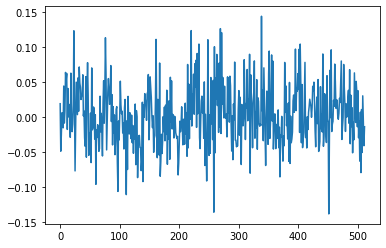

In [103]:
plt.plot(net.lpe[ -1, :].detach().cpu().numpy())

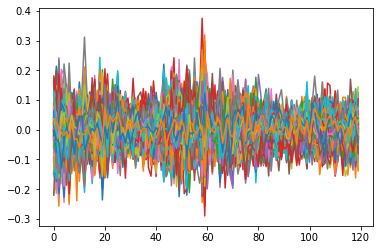

In [104]:
for i in range(net.lpe.size(-1)):
    plt.plot(net.lpe[:, i].detach().cpu().numpy())

In [105]:
#net.load_state_dict(torch.load("wavenet_2.bin"))

In [106]:
torch.save(net.state_dict(), "wavenet_4.bin")
# Now ready to use in Pyphonic!

In [107]:
x_f = np.zeros([0, 1])
t_f = np.zeros([0, 1])
y_f = np.zeros([0, 1])

net.eval();

bs = 1
net.init_hidden(1)
dataloader = DataLoader(WaveDataGenerator(num_prev_states=num_prev_states,
                                          start=num_prev_states, num_blocks=2500,
                                          input_file='c:/Users/tomgr/Desktop/melange_10.wav',
                                          target_file='c:/Users/tomgr/Desktop/melange_10_delayfreq120.wav'),
                                          batch_size=bs, shuffle=False, drop_last=True)

for j, batch in enumerate(dataloader):#8100, 8103):
    x, target = batch
    with torch.no_grad():
        yhat = net(x)
    out = yhat[0].detach().cpu().numpy()
    x_f = np.append(x_f, x[:, -1, -512:].detach().cpu().numpy())
    t_f = np.append(t_f, target.detach().cpu().numpy())
    y_f = np.append(y_f, out[-512:])

length in 512 size blocks:  27858
27857 27857


In [108]:
import scipy.io.wavfile as sw
sw.write("c:/Users/tomgr/Desktop/x_f.wav", 44100, x_f.astype(np.float32))
sw.write("c:/Users/tomgr/Desktop/t_f.wav", 44100, t_f.astype(np.float32))
sw.write("c:/Users/tomgr/Desktop/y_f.wav", 44100, y_f.astype(np.float32))

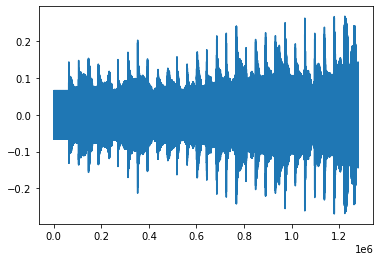

In [109]:
plt.plot(x_f)

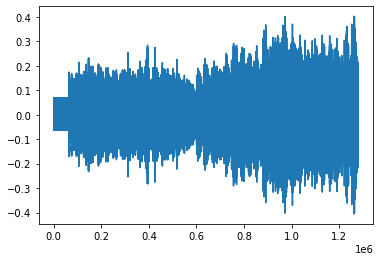

In [110]:
plt.plot(t_f)

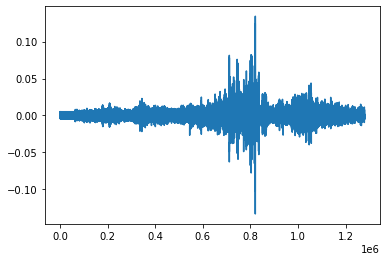

In [111]:
plt.plot(y_f)